# Project 1 — The Price of Fairness: Constrained Pricing and the Frontier

**The centerpiece.** The baseline prices risk accurately but "unfairly" (M/C pays 3.3x F/A). Now we ask the project's title question with mathematics:

> What does fairness actually cost — in accuracy, in money moved, and in calibration?

## Formulation

Let $p_i$ be the baseline pure premium for policy $i$ and $\lambda_g$ a segment-level multiplier (segment = gender x territory). Constrained premiums are $p'_i = \lambda_{g(i)} p_i$, chosen to

$$\min_{\lambda} \; \frac{1}{n}\sum_i \left(p'_i - y_i\right)^2 \quad \text{s.t.} \quad \left|\,\overline{p'}_{\,h} - \mu\,\right| \le \varepsilon\, \mu \;\; \forall h \;\;\text{and}\;\; \sum_i p'_i = \sum_i p_i$$

where $\overline{p'}_{\,h}$ is the mean premium of protected group $h$, $\mu$ the overall mean, and $\varepsilon$ the allowed parity gap. This is a convex quadratic program (solved exactly with OSQP). Sweeping $\varepsilon$ from the baseline gap to 0 traces the **accuracy-fairness frontier**; $\varepsilon = 0$ is full demographic parity on premiums.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.load import load_claims
from src.models import fit_frequency_model, fit_severity_model
from src.fairness import add_predictions
from src.frontier import ConstrainedPricing

plt.rcParams["figure.dpi"] = 110
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

df = load_claims(ROOT / "data" / "sample_claims.csv")
freq = fit_frequency_model(df)
sev = fit_severity_model(df)
scored = add_predictions(df, freq, sev)
print(f"Scored {len(scored):,} policies | overall mean premium: ${scored['predicted_premium'].mean():,.2f}")

Scored 10,000 policies | overall mean premium: $479.76


## Segment-level frontier (gender x territory)

Each point is an optimal multiplier vector for a given allowed gap $\varepsilon$. `cost_mse` is the extra squared error (vs the unconstrained optimum), `fairness_gap` the realized relative premium range, `redistribution` the share of premium volume that changes hands.

In [2]:
cp = ConstrainedPricing(scored)
frontier_seg = cp.frontier(n_points=13)
print(frontier_seg[["eps", "cost_mse", "fairness_gap", "redistribution"]].round(4).to_string(index=False))

   eps  cost_mse  fairness_gap  redistribution
1.3130    0.0000        1.4479          0.0586
1.2036    0.0000        1.4479          0.0586
1.0942    0.0000        1.4479          0.0586
0.9848    0.0000        1.4479          0.0586
0.8754    0.0000        1.3923          0.0517
0.7659    0.0003        1.2674          0.0624
0.6565    0.0009        1.1425          0.0777
0.5471    0.0018        1.0020          0.0909
0.4377    0.0035        0.8546          0.1216
0.3283    0.0059        0.6565          0.1779
0.2188    0.0092        0.4377          0.2342
0.1094    0.0138        0.2188          0.2905
0.0000    0.0200        0.0000          0.3530


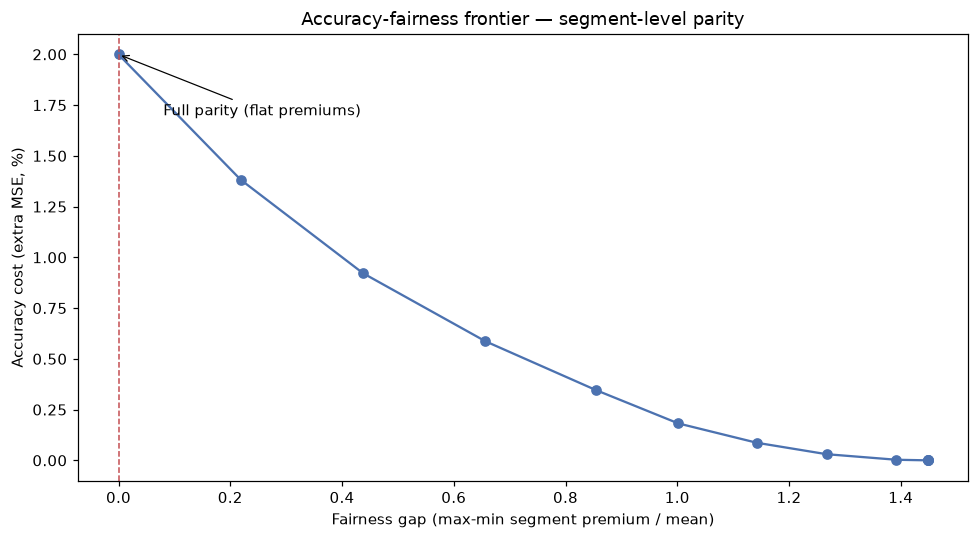

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frontier_seg["fairness_gap"], frontier_seg["cost_mse"] * 100, "o-", color="#4C72B0")
ax.axvline(frontier_seg["fairness_gap"].iloc[-1], color="#C44E52", ls="--", lw=1)
ax.annotate("Full parity (flat premiums)", xy=(0.0, frontier_seg["cost_mse"].iloc[-1] * 100),
            xytext=(0.08, 1.7), arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_xlabel("Fairness gap (max-min segment premium / mean)")
ax.set_ylabel("Accuracy cost (extra MSE, %)")
ax.set_title("Accuracy-fairness frontier — segment-level parity")
plt.tight_layout()
plt.savefig(RESULTS / "frontier_segment.png", dpi=150)
plt.show()

## Who pays: redistribution at full parity

At $\varepsilon = 0$ every segment pays the same mean premium ($\mu$). Cheap segments become more expensive and expensive segments cheaper — that money is the price of equality.

In [4]:
lam_full = cp.solve(0.0)
red_full = cp.redistribution_table(lam_full)
print(red_full.to_string(index=False))

segment  n_policies  baseline_premium  constrained_premium  change  change_pct  total_moved  is_payer
 (F, A)        2039            271.62               479.76  208.14       76.63    424399.14     False
 (M, A)        1919            347.57               479.76  132.19       38.03    253680.05     False
 (F, B)        1796            385.87               479.76   93.89       24.33    168626.71     False
 (M, B)        1674            488.65               479.76   -8.89       -1.82    -14882.04      True
 (F, C)        1332            711.58               479.76 -231.82      -32.58   -308779.79      True
 (M, C)        1240            901.57               479.76 -421.81      -46.79   -523044.07      True


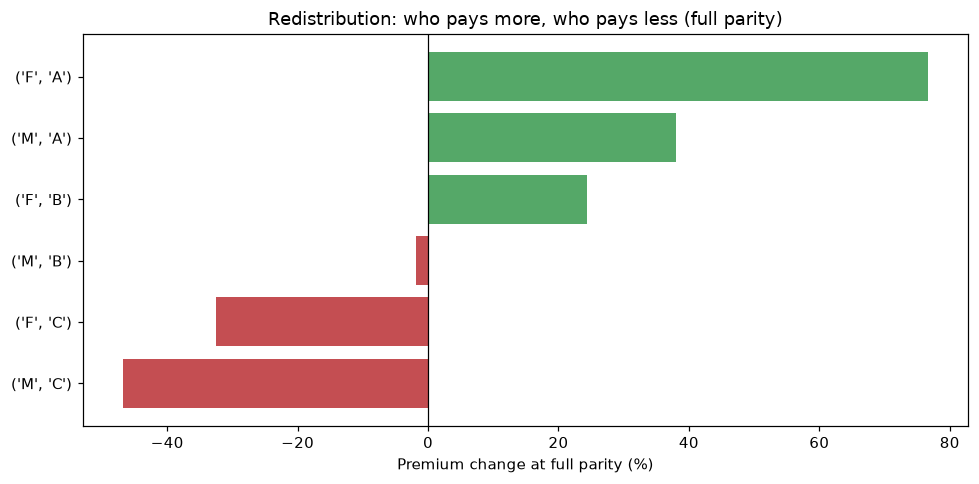

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = red_full.sort_values("change_pct")["segment"]
colors = ["#C44E52" if x < 0 else "#55A868" for x in red_full.set_index("segment").loc[order, "change_pct"]]
ax.barh([str(s) for s in order], red_full.set_index("segment").loc[order, "change_pct"], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Premium change at full parity (%)")
ax.set_title("Redistribution: who pays more, who pays less (full parity)")
plt.tight_layout()
plt.savefig(RESULTS / "redistribution_full_parity.png", dpi=150)
plt.show()

## The calibration-fairness trade-off (Chouldechova in pricing terms)

The baseline is calibrated: each segment's premium matches its actual loss (ratio ~1). Constrained pricing deliberately breaks that — if every segment pays the same, high-risk segments are undercharged and low-risk overcharged. That is the pricing version of the impossibility result: parity and calibration cannot both hold when base rates differ.

In [6]:
def calibration_ratios(lam):
    pred = scored["predicted_premium"].to_numpy() * lam[cp.seg]
    rows = []
    for g in range(cp.n_segments):
        mask = cp.seg == g
        rows.append({
            "segment": cp.segment_names[g],
            "baseline_ratio": scored.loc[mask, "predicted_premium"].mean() / scored.loc[mask, "total_claim_amount"].mean(),
            "parity_ratio": pred[mask].mean() / scored.loc[mask, "total_claim_amount"].mean(),
        })
    return pd.DataFrame(rows).round(3)

cal = calibration_ratios(lam_full)
print(cal.to_string(index=False))
cal.to_csv(RESULTS / "calibration_tradeoff.csv", index=False)

segment  baseline_ratio  parity_ratio
 (F, A)           1.035         1.827
 (F, B)           1.033         1.284
 (F, C)           0.953         0.642
 (M, A)           1.005         1.387
 (M, B)           0.935         0.918
 (M, C)           1.007         0.536


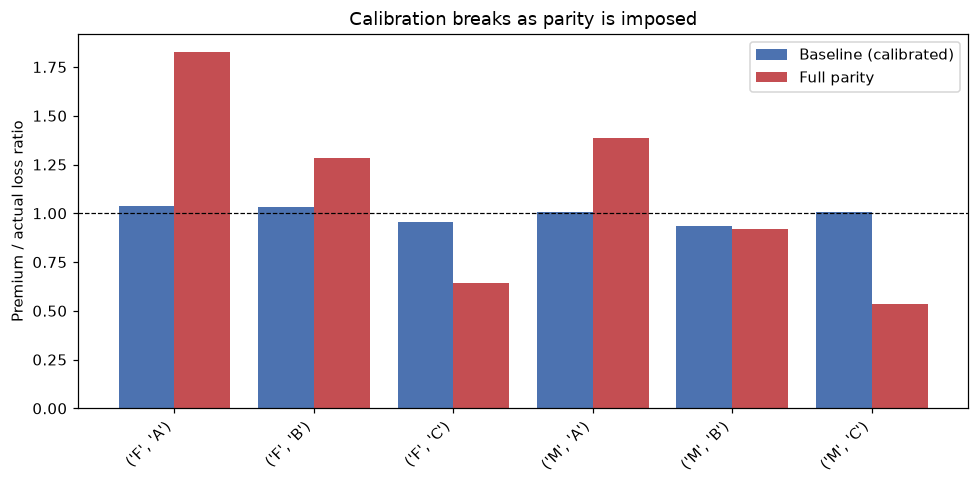

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(cal))
ax.bar(x - 0.2, cal["baseline_ratio"], 0.4, label="Baseline (calibrated)", color="#4C72B0")
ax.bar(x + 0.2, cal["parity_ratio"], 0.4, label="Full parity", color="#C44E52")
ax.axhline(1.0, color="k", lw=0.8, ls="--")
ax.set_xticks(x); ax.set_xticklabels([str(s) for s in cal["segment"]], rotation=45, ha="right")
ax.set_ylabel("Premium / actual loss ratio")
ax.set_title("Calibration breaks as parity is imposed")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "calibration_tradeoff.png", dpi=150)
plt.show()

## A cheaper policy: gender-level parity only

A regulator banning *gender* (the EU's actual rule) constrains only the two gender means, leaving territory differences alone. The frontier looks very different.

In [8]:
cp_gender = ConstrainedPricing(scored, parity_cols=("gender",))
frontier_gen = cp_gender.frontier(n_points=11)
print(frontier_gen[["eps", "cost_mse", "fairness_gap", "redistribution"]].round(4).to_string(index=False))

lam_gender = cp_gender.solve(0.0)
red_gender = cp_gender.redistribution_table(lam_gender)
print()
print(red_gender[["segment", "baseline_premium", "constrained_premium", "change_pct"]].round(2).to_string(index=False))

   eps  cost_mse  fairness_gap  redistribution
0.2373    0.0000        0.2883          0.0586
0.2135    0.0000        0.2883          0.0586
0.1898    0.0000        0.2883          0.0586
0.1661    0.0000        0.2883          0.0586
0.1424    0.0000        0.2755          0.0565
0.1186    0.0001        0.2296          0.0486
0.0949    0.0002        0.1837          0.0463
0.0712    0.0005        0.1378          0.0567
0.0475    0.0008        0.0918          0.0726
0.0237    0.0012        0.0459          0.0956
0.0000    0.0018        0.0000          0.1185

segment  baseline_premium  constrained_premium  change_pct
 (F, C)            711.58               825.31       15.98
 (F, B)            385.87               432.80       12.16
 (F, A)            271.62               295.40        8.75
 (M, B)            488.65               448.01       -8.32
 (M, C)            901.57               851.90       -5.51
 (M, A)            347.57               267.00      -23.18


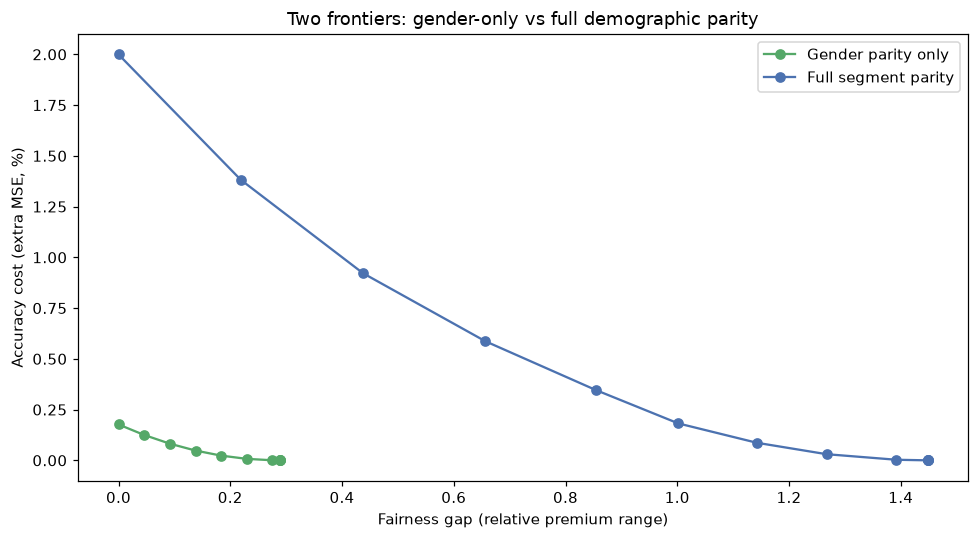

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frontier_gen["fairness_gap"], frontier_gen["cost_mse"] * 100, "o-", color="#55A868", label="Gender parity only")
ax.plot(frontier_seg["fairness_gap"], frontier_seg["cost_mse"] * 100, "o-", color="#4C72B0", label="Full segment parity")
ax.set_xlabel("Fairness gap (relative premium range)")
ax.set_ylabel("Accuracy cost (extra MSE, %)")
ax.set_title("Two frontiers: gender-only vs full demographic parity")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "frontier_comparison.png", dpi=150)
plt.show()

## Save results for the dashboard

In [10]:
frontier_seg.to_csv(RESULTS / "frontier_segment.csv", index=False)
frontier_gen.to_csv(RESULTS / "frontier_gender.csv", index=False)
red_full.to_csv(RESULTS / "redistribution_full_parity.csv", index=False)
red_gender.to_csv(RESULTS / "redistribution_gender_parity.csv", index=False)

# Wide dashboard table: constrained segment premium at every frontier point
seg_mean = scored.groupby(cp.segment_cols, observed=True)["predicted_premium"].mean()
dash = frontier_seg[["eps", "cost_mse", "fairness_gap", "redistribution"]].copy()
for g, name in enumerate(cp.segment_names):
    dash[f"premium_{name[0]}_{name[1]}"] = (frontier_seg[f"multiplier_{g}"] * seg_mean.iloc[g]).round(2)
dash.to_csv(RESULTS / "dashboard_frontier.csv", index=False)

seg_summary = pd.DataFrame({
    "segment": [str(s) for s in cp.segment_names],
    "baseline_premium": seg_mean.round(2).values,
    "full_parity_premium": (seg_mean * lam_full).round(2).values,
    "gender_parity_premium": (seg_mean * lam_gender).round(2).values,
})
seg_summary.to_csv(RESULTS / "segment_summary.csv", index=False)
print("saved:", sorted(p.name for p in RESULTS.iterdir()))

saved: ['calibration_tradeoff.csv', 'calibration_tradeoff.png', 'dashboard_frontier.csv', 'frontier_comparison.png', 'frontier_gender.csv', 'frontier_segment.csv', 'frontier_segment.png', 'redistribution_full_parity.csv', 'redistribution_full_parity.png', 'redistribution_gender_parity.csv', 'segment_summary.csv']


## Interpretation

* **Full demographic parity is expensive in design space, not in dollars:** flattening all six segment means costs +2.0% MSE but moves 35% of premium volume — a massive cross-subsidy from low-risk (F/A, M/A) to high-risk (M/C, F/C) segments.
* **Banning one variable is cheap:** gender-only parity costs just +0.18% MSE and moves 12% of volume, because territory (a larger risk driver) still does the pricing work. This is the EU's experience made quantitative.
* **The frontier is the deliverable:** it converts a philosophical debate into a curve a regulator, CEO, or actuary can argue about — *how much accuracy are you willing to trade for how much parity?*
* **Calibration is the casualty:** parity and calibration cannot both hold (Chouldechova), and the tables show exactly where the break happens.
* **Caveats:** segment-multiplier post-processing is one family of constrained-pricing methods; per-policy optimization and other fairness definitions (equalized odds on claim rates) would shift the curve. The synthetic data fixes the ground truth, so the *shape* of the frontier is the result, not the absolute numbers.